In [1]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.optim import AdamW
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import metrics

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [2]:
df_electron = pd.read_csv("../../Data_Separated/Bias/Filter_By_MLP/electron.csv")
df_muon = pd.read_csv("../../Data_Separated/Bias/Filter_By_MLP/muon.csv")
print(df_electron.shape)
print(df_muon.shape)
print(df_muon.columns)

(107613, 11)
(505664, 11)
Index(['track_TRTHits', 'track_PixelHits', 'track_SCTHits', 'track_PixeldEdX',
       'topo_cluster_eta', 'topo_cluster_phi', 'topo_cluster_EM_prob',
       'topo_cluster_pt', 'pt_ratio', 'topo_cluster_lambda',
       'topo_cluster_lambda2'],
      dtype='object')


In [3]:
#filtering
df_electron_clean = df_electron[
    (df_electron['topo_cluster_eta'] != -10.0) &
    (df_electron['topo_cluster_pt'] != -1.0) &
    (df_electron['topo_cluster_phi'] != -10.0) &
    (df_electron['topo_cluster_EM_prob'] != -1.0) &
    (df_electron['pt_ratio'] != -1.0) &
    (df_electron['topo_cluster_lambda'] != -1.0) &
    (df_electron['topo_cluster_lambda2'] != -1.0)
]

df_muon_clean = df_muon[
    (df_muon['topo_cluster_eta'] != -10.0) &
    (df_muon['topo_cluster_pt'] != -1.0) &
    (df_muon['topo_cluster_phi'] != -10.0) &
    (df_muon['topo_cluster_EM_prob'] != -1.0) &
    (df_muon['pt_ratio'] != -1.0) &
    (df_muon['topo_cluster_lambda'] != -1.0) &
    (df_muon['topo_cluster_lambda2'] != -1.0)
]

df_electron_clean['label'] = 1  # Electrons = 1
df_muon_clean['label'] = 0

df_full = pd.concat([df_electron_clean, df_muon_clean], ignore_index=True)

C:\Users\qmiko\AppData\Local\Temp\ipykernel_18452\616011081.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_muon_clean['label'] = 0


In [4]:
num_muons = df_muon_clean.shape[0]
num_elec = df_electron_clean.shape[0]
pos_weight = torch.tensor(1.5*num_muons/num_elec).to(DEVICE)
print(num_muons)
print(num_elec)

379983
107613


In [5]:
feature_columns = [
"track_TRTHits",
"track_PixelHits",
"track_SCTHits",
"track_PixeldEdX",
"topo_cluster_eta",
"topo_cluster_phi",
"topo_cluster_EM_prob",
"topo_cluster_pt",
"pt_ratio",
"topo_cluster_lambda",
"topo_cluster_lambda2"
]

x_data = df_full[feature_columns]  # 11 features
y_data = df_full['label']  

test_size = 0.2
x_train, x_val, y_train, y_val = train_test_split(x_data.values, y_data.values, test_size=test_size, shuffle=True)


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)



In [6]:
print(np.shape(x_train))
print(np.shape(x_val))
print(np.shape(y_train))
print(np.shape(y_val))
in_data = np.shape(x_train)[1]

torch.Size([390076, 11])
torch.Size([97520, 11])
torch.Size([390076])
torch.Size([97520])


In [7]:
class Linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(in_data, 20),
            nn.ReLU(),
            nn.Linear(20, 40),
            nn.ReLU(),
            nn.Linear(40, 60),
            nn.ReLU(),
            nn.Linear(60, 40),
            nn.ReLU(),
            nn.Linear(40, 20),
            nn.ReLU(),
            nn.Linear(20, 1)
        )

    def forward(self, sample):
        return self.linear(sample)
    
    def param(self):
        count = 0
        for parameter in self.parameters():
            count += parameter.numel()
        return count

In [8]:
num_elec_val = (y_val == 1).sum().item()
num_muons_val = (y_val == 0).sum().item()

In [9]:
def train(model, epochs):
    optimizer = AdamW(model.parameters())
    loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    loss_history = []
    accuracy_el = []
    accuracy_mu = []
    for epoch in range(epochs):
        score_el = 0.0
        score_mu = 0.0
        acc_el = 0.0
        acc_mu = 0.0
        los = 0.0
    
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()
        for batch in train_loader:
            sample, true = batch
            sample = sample.to(DEVICE)
            true = true.to(DEVICE)
            pred = model(sample)[:,0]
            l = loss(pred, true)
            l.backward()
            optimizer.step()
            optimizer.zero_grad()
            
        model.eval()
        for batch in val_loader:
            sample, true = batch
            sample = sample.to(DEVICE)
            true = true.to(DEVICE)
            pred = model(sample)[:,0]
            l = loss(pred, true)
            los += l.item()
            
            pred = torch.sigmoid(pred)
            pred = (pred >= 0.5).float()
            
            score_el += ((true == 1) & (pred == 1)).sum().item()
            score_mu += ((true == 0) & (pred == 0)).sum().item()
                
            
        loss_history.append(los/len(val_loader))
        acc_el = score_el/num_elec_val
        acc_mu = score_mu/num_muons_val
        accuracy_el.append(acc_el)
        accuracy_mu.append(acc_mu)
        print(f"Electron Accuracy: {acc_el*100}")
        print(f"Muon Accuracy: {acc_mu*100}\n")
        
    return model, loss_history, accuracy_el, accuracy_mu

In [10]:
model = Linear().to(DEVICE)
print(model.param())
model, loss, ac_el, ac_mu =train(model, 15)

6821
Epoch 1/15
Electron Accuracy: 100.0
Muon Accuracy: 99.75798708387589

Epoch 2/15
Electron Accuracy: 99.99069377879111
Muon Accuracy: 99.98947769929896

Epoch 3/15
Electron Accuracy: 99.98604066818669
Muon Accuracy: 99.99342356206185

Epoch 4/15
Electron Accuracy: 99.99069377879111
Muon Accuracy: 99.99868471241237

Epoch 5/15
Electron Accuracy: 100.0
Muon Accuracy: 99.98290126136081

Epoch 6/15
Electron Accuracy: 100.0
Muon Accuracy: 99.99736942482474

Epoch 7/15
Electron Accuracy: 99.99534688939556
Muon Accuracy: 99.99605413723711

Epoch 8/15
Electron Accuracy: 99.98604066818669
Muon Accuracy: 99.99736942482474

Epoch 9/15
Electron Accuracy: 100.0
Muon Accuracy: 99.99605413723711

Epoch 10/15
Electron Accuracy: 99.99534688939556
Muon Accuracy: 99.9697483854845

Epoch 11/15
Electron Accuracy: 99.99069377879111
Muon Accuracy: 99.99342356206185

Epoch 12/15
Electron Accuracy: 100.0
Muon Accuracy: 99.99605413723711

Epoch 13/15
Electron Accuracy: 99.99534688939556
Muon Accuracy: 99.99

In [ ]:
example_input, _ = next(iter(val_loader))
example_input = example_input[:1].to(DEVICE)
scripted = torch.jit.trace(model, example_input)
scripted.save("trained/model_trained_on_filtered.pt")
import joblib
joblib.dump(scaler, "trained/scaler_mlp2.pkl")

['trained/scaler_mlp2.pkl']

In [12]:
import joblib

model1 = torch.jit.load("trained/model-filter.pt").to(DEVICE)
model2 = torch.jit.load("trained/model_trained_on_filtered.pt").to(DEVICE)

# 1. Wczytaj
df_elec_test = pd.read_csv("../../Data_Separated/MC/electron.csv")
df_muon_test = pd.read_csv("../../Data_Separated/MC/muon.csv")

# 2. Filtruj (identycznie jak dane treningowe) — BUG 3
FILTER = lambda df: df[
    (df['topo_cluster_eta']   != -10.0) &
    (df['topo_cluster_pt']    !=  -1.0) &
    (df['topo_cluster_phi']   != -10.0) &
    (df['topo_cluster_EM_prob']!= -1.0) &
    (df['pt_ratio']           !=  -1.0) &
    (df['topo_cluster_lambda'] != -1.0) &
    (df['topo_cluster_lambda2']!= -1.0)
]
df_elec_test = FILTER(df_elec_test)
df_muon_test = FILTER(df_muon_test)

# 3. Dodaj label po filtracji — BUG A
df_elec_test = df_elec_test.copy(); df_elec_test['label'] = 1
df_muon_test = df_muon_test.copy(); df_muon_test['label'] = 0

# 4. Concat
df_full = pd.concat([df_elec_test, df_muon_test], ignore_index=True)

print("Number of muon:", df_muon_test.shape[0])
print("Number of elec:", df_elec_test.shape[0])

feature_columns = [
    "track_TRTHits", "track_PixelHits", "track_SCTHits", "track_PixeldEdX",
    "topo_cluster_eta", "topo_cluster_phi", "topo_cluster_EM_prob",
    "topo_cluster_pt", "pt_ratio", "topo_cluster_lambda", "topo_cluster_lambda2"
]

x_data = df_full[feature_columns]
y_data = df_full['label']

idx = np.random.choice(len(df_full), size=100000, replace=False)
x_data = df_full[feature_columns].iloc[idx]
y_data = df_full['label'].iloc[idx]

# 5. Załaduj właściwe scalery — BUG 1
scaler1 = joblib.load("trained/scaler_mlp1.pkl")
scaler2 = joblib.load("trained/scaler_mlp2.pkl")

x_data1 = torch.tensor(scaler1.transform(x_data), dtype=torch.float32)
x_data2 = torch.tensor(scaler2.transform(x_data), dtype=torch.float32)
y_data  = torch.tensor(y_data.values, dtype=torch.float32)

# 6. Osobne DataLoadery dla każdego modelu — BUG B
loader1 = DataLoader(TensorDataset(x_data1, y_data), batch_size=64, shuffle=False)
loader2 = DataLoader(TensorDataset(x_data2, y_data), batch_size=64, shuffle=False)

# 7. Liczniki z przefiltrowanych danych
num_elec_val  = (y_data == 1).sum().item()
num_muons_val = (y_data == 0).sum().item()

def evaluate(model, loader):
    score_el = score_mu = 0
    with torch.no_grad():
        model.eval()
        for sample, true in loader:
            sample, true = sample.to(DEVICE), true.to(DEVICE)
            prob = torch.sigmoid(model(sample)[:, 0])
            pred = (prob >= 0.5).float()
            score_el += ((true == 1) & (pred == 1)).sum().item()
            score_mu += ((true == 0) & (pred == 0)).sum().item()
    return score_el / num_elec_val, score_mu / num_muons_val

acc_el_1, acc_mu_1 = evaluate(model1, loader1)
acc_el_2, acc_mu_2 = evaluate(model2, loader2)

print(f"MODEL 1 — Electron: {acc_el_1*100:.2f}%  Muon: {acc_mu_1*100:.2f}%")
print(f"MODEL 2 — Electron: {acc_el_2*100:.2f}%  Muon: {acc_mu_2*100:.2f}%")

Number of muon: 954537
Number of elec: 350548


c:\Users\qmiko\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\qmiko\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


MODEL 1 — Electron: 97.74%  Muon: 98.54%
MODEL 2 — Electron: 97.67%  Muon: 98.68%


In [13]:
# Zamiast x_val używaj danych MC dla model2
with torch.no_grad():
    model2.eval()
    prob_norm = torch.sigmoid(model2(x_data2.to(DEVICE))[:, 0]).cpu().numpy()

y_true = y_data.cpu().numpy()

print("mean prob electron:", prob_norm[y_true==1].mean())
print("mean prob muon:    ", prob_norm[y_true==0].mean())
print("min:", prob_norm.min(), "max:", prob_norm.max())
print("prob > 0.5:", (prob_norm > 0.5).sum(), "/ total:", len(prob_norm))

mean prob electron: 0.97679806
mean prob muon:     0.0136460485
min: 0.0 max: 1.0
prob > 0.5: 27175 / total: 100000


Najlepszy próg (Youden): 0.000
Electron: 95.73%  Muon: 95.58%


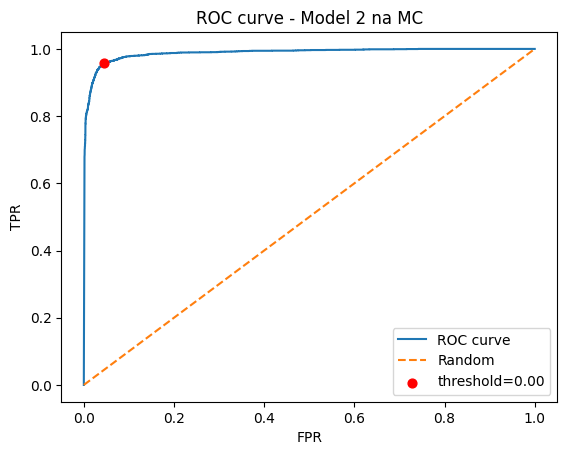

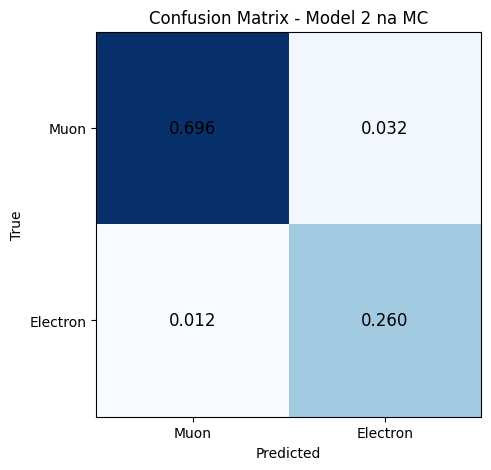

In [18]:
fpr, tpr, thresholds = metrics.roc_curve(y_true, prob_norm)
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(f"Najlepszy próg (Youden): {best_thresh:.3f}")

# Accuracy przy best_thresh
pred_best = (prob_norm >= best_thresh).astype(int)
num_el = (y_true == 1).sum()
num_mu = (y_true == 0).sum()
acc_el = ((pred_best == 1) & (y_true == 1)).sum() / num_el
acc_mu = ((pred_best == 0) & (y_true == 0)).sum() / num_mu
print(f"Electron: {acc_el*100:.2f}%  Muon: {acc_mu*100:.2f}%")

# ROC plot
plt.figure()
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0,1],[0,1], '--', label='Random')
plt.scatter(fpr[ix], tpr[ix], c='red', s=40, zorder=2, label=f'threshold={best_thresh:.2f}')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC curve - Model 2 na MC")
plt.legend(); plt.savefig("Plot_roc_mc.png"); plt.show()

# Confusion matrix
mat = metrics.confusion_matrix(y_true, pred_best) / len(y_true)
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(mat, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center", fontsize=12)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Muon","Electron"]); ax.set_yticklabels(["Muon","Electron"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Model 2 na MC")
plt.savefig("Plot_matrix_mc.png"); plt.show()

In [ ]:
# Próg = mediana prawdopodobieństw elektronów
el_probs = prob_norm[y_true == 1]
mu_probs = prob_norm[y_true == 0]

print(f"Elektrony — mediana: {np.median(el_probs):.4f}, p5: {np.percentile(el_probs, 5):.4f}")
print(f"Miony     — mediana: {np.median(mu_probs):.4f}, p95: {np.percentile(mu_probs, 95):.4f}")

# Próg w połowie między p95 mionów a p5 elektronów
best_thresh = (np.percentile(mu_probs, 95) + np.percentile(el_probs, 5)) / 2
print(f"Próg fizyczny: {best_thresh:.4f}")

# Próg = mediana prawdopodobieństw elektronów
el_probs = prob_norm[y_true == 1]
mu_probs = prob_norm[y_true == 0]

print(f"Elektrony — mediana: {np.median(el_probs):.4f}, p5: {np.percentile(el_probs, 5):.4f}")
print(f"Miony     — mediana: {np.median(mu_probs):.4f}, p95: {np.percentile(mu_probs, 95):.4f}")

# Próg w połowie między p95 mionów a p5 elektronów
best_thresh = (np.percentile(mu_probs, 95) + np.percentile(el_probs, 5)) / 2
print(f"Próg fizyczny: {best_thresh:.4f}")

pred_05 = (prob_norm >= 0.5).astype(int)
acc_el = ((pred_05 == 1) & (y_true == 1)).sum() / (y_true == 1).sum()
acc_mu = ((pred_05 == 0) & (y_true == 0)).sum() / (y_true == 0).sum()
print(f"Próg 0.5 — Electron: {acc_el*100:.2f}%  Muon: {acc_mu*100:.2f}%")

Elektrony — mediana: 1.0000, p5: 0.0000
Miony     — mediana: 0.0000, p95: 0.0000
Próg fizyczny: 0.0000
Elektrony — mediana: 1.0000, p5: 0.0000
Miony     — mediana: 0.0000, p95: 0.0000
Próg fizyczny: 0.0000


Najlepszy próg: inf


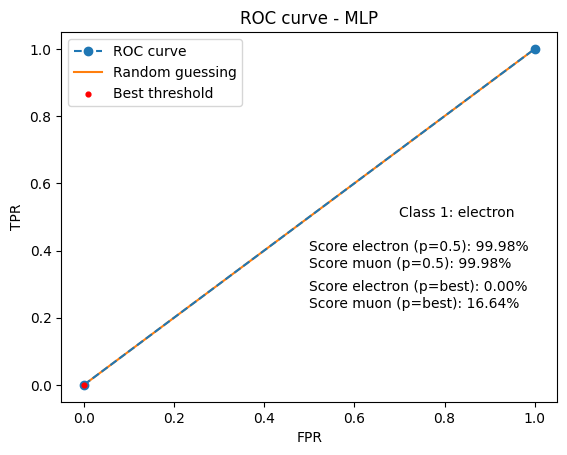

In [25]:
#ROC CURVE AND BEST THRESHOLD
model.eval()
model = model.to(DEVICE)
x_data = x_data.to(DEVICE)
pred = model(x_data)
prob_norm = torch.sigmoid(pred).detach().cpu().numpy().ravel()
y_true = y_data.cpu().numpy().ravel()

fpr, tpr, thresholds = metrics.roc_curve(y_true, prob_norm)  # dla 1 czyli mionelektrony
plt.plot(fpr, tpr, 'o--', zorder = 1, label='ROC curve')
plt.plot([0,1],[0,1], zorder=0, label = 'Random guessing')
plt.title("ROC curve - MLP")
plt.text(0.7,0.5, 'Class 1: electron')
plt.text(0.5,0.4, f'Score electron (p=0.5): {ac_el[argm]*100:.2f}% ')
plt.text(0.5,0.35, f'Score muon (p=0.5): {ac_mu[argm]*100:.2f}% ')

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(f"Najlepszy próg: {best_thresh:.3f}")

score_el = 0.0
score_mu = 0.0

for batch in val_loader:
    sample, true = batch
    sample = sample.to(DEVICE)
    true = true.to(DEVICE)
    pred = model(sample)[:,0]
    
    pred = torch.sigmoid(pred)
    pred = (pred >= best_thresh).float()
    
    score_el += ((true == 1) & (pred == 1)).sum().item()
    score_mu += ((true == 0) & (pred == 0)).sum().item()
        
    
acc_el = score_el/(num_elec_val)
acc_mu = score_mu/(num_muons_val)


plt.text(0.5,0.28, f'Score electron (p=best): {acc_el*100:.2f}% ')
plt.text(0.5,0.23, f'Score muon (p=best): {acc_mu*100:.2f}% ')
plt.scatter(fpr[ix], tpr[ix], c='red', s=12, zorder =2, label = 'Best threshold')
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
# plt.savefig(r"C:\Users\qmiko\Desktop\cern\Plots_ml\Mlp_roc.png")
plt.show()

In [24]:
print(prob_norm.shape)

(1400000,)


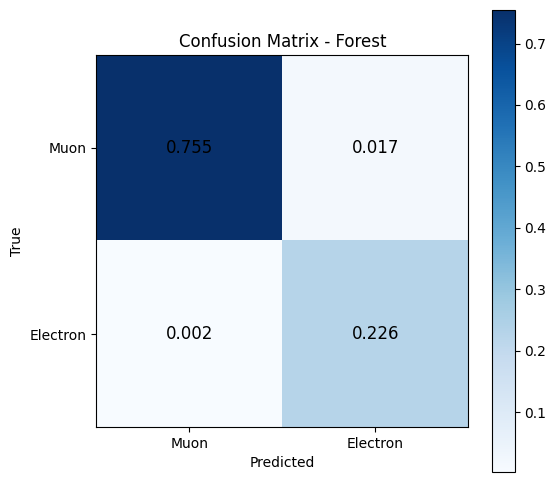

In [ ]:
true = y_val

model.eval()
model = model.to(DEVICE)
x_val = x_val.to(DEVICE)
pred = model(x_val)
prob_norm = torch.sigmoid(pred).detach().cpu().numpy()

pred_th = (prob_norm >= best_thresh).astype(int) #1 to elektorn i to jest jako Positive
mat = metrics.confusion_matrix(true, pred_th)
mat = mat/np.sum(mat)

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(mat, cmap='Blues')

# dodanie kolorowego paska obok
cbar = ax.figure.colorbar(im, ax=ax)


# podpisy osi
classes = ["Muon", "Electron"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Forest")


# dopisywanie wartości w komórkach
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", color="black", fontsize=12)

# plt.savefig(r"C:\Users\qmiko\Desktop\cern\Plots_ml\Mlp_matrix.png")
plt.show()

In [ ]:
example_input, _ = next(iter(val_loader))
example_input = example_input[:1].to(DEVICE)
scripted = torch.jit.trace(model, example_input)
scripted.save("trained/model.pt")